# Customer Churn Prediction Using Artificial Neural Network (ANN)

## Project Objective

The goal of this project is to build an Artificial Neural Network (ANN)
that predicts whether a customer is likely to churn based on their
demographic information, services, contract details, and billing information.



In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
# load the dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [88]:
#preview dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [89]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [90]:
# rows and columns
df.shape

(7043, 21)

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [92]:
# column name

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [93]:
# missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [94]:
# Checking for Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [95]:
#Statistical Summary

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [96]:
df.describe(include="object")

C:\Users\muham\AppData\Local\Temp\ipykernel_4896\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Target Variable

The target variable is `Churn`.

It contains two possible values:

- `Yes` — customer churned
- `No` — customer did not churn

In [97]:
## check churn counts

df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Visualize Churn Distribution

A bar chart helps us visually compare the number of customers who
churned with the number of customers who did not churn.

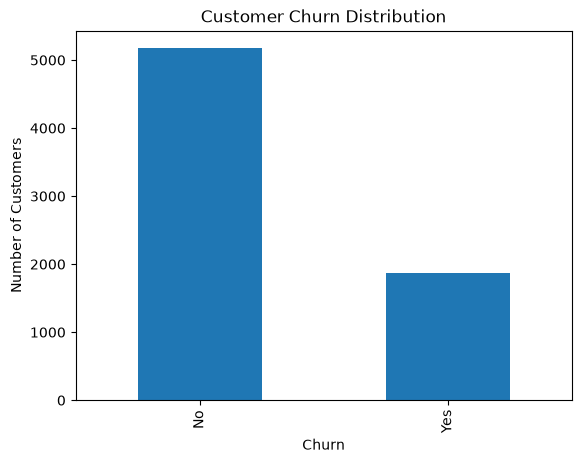

In [98]:
## visualizing churn distribution

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Convert TotalCharges to Numeric

The `TotalCharges` column represents the total amount charged to a customer.
However, it is stored as an object because some rows contain blank values.

We convert the column to a numeric data type. Invalid values are converted
to NaN so that they can be handled during preprocessing.

In [99]:
df["TotalCharges"]=pd.to_numeric (df["TotalCharges"],errors="coerce")

In [100]:
df["TotalCharges"].isnull().sum()

np.int64(11)

## Handle Missing Values in TotalCharges

The `TotalCharges` column contains 11 missing values after converting
the column to numeric.

These records correspond to customers with zero tenure, so their
total charges can reasonably be represented as 0.

In [101]:
df['TotalCharges'] = df["TotalCharges"].fillna(0)

In [102]:
df["TotalCharges"].isnull().sum()

np.int64(0)

##  Verify Data Types

After cleaning `TotalCharges`, we check the data types again to confirm
that the column has been successfully converted from `object` to a
numeric data type.

In [103]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

## Remove Unnecessary Columns

The `customerID` column is a unique identifier for each customer.
It does not provide useful predictive information for customer churn,
so it is removed before model training.

In [104]:
df.drop('customerID', axis=1,inplace= True)

In [105]:
# checking the columns

df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

So, the next step is Identify Categorical contain values that represent categories rather than continuous numerical measurements.

These columns must be converted into numerical representations before
they can be used by the neural network.

In [106]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

C:\Users\muham\AppData\Local\Temp\ipykernel_4896\1797605437.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

## 18. Separate Features and Target

The dataset is divided into:

- `X` — input features used by the neural network to make predictions.
- `y` — target variable that the neural network will learn to predict.

For this project, `Churn` is the target variable.

In [107]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

In [108]:
x.shape

(7043, 19)

In [109]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str

## Encode the Target Variable

The `Churn` target contains two categorical values: `Yes` and `No`.

Since this is a binary classification problem, we convert the target
into numerical values:

- `Yes` → 1
- `No` → 0

In [110]:
y = y.map({"Yes": 1, "No": 0})

In [111]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

## Encode Categorical Features

Categorical input features must be converted into numerical values before
they can be used by the neural network.

We use one-hot encoding for categorical features. One-hot encoding creates
a separate binary column for each category.

In [112]:
 ## Eencoding

x = pd.get_dummies(x, drop_first=True)
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [113]:
x.shape

(7043, 30)

## Train-test Split

The dataset is divided into training and testing sets.

- Training data is used to teach the neural network.
- Testing data is used to evaluate how well the trained model performs
  on previously unseen data.

We use 80% of the data for training and 20% for testing.

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##  Build the Artificial Neural Network

We use TensorFlow and Keras to create an Artificial Neural Network (ANN).

The network contains two hidden layers using ReLU activation and one
output neuron using Sigmoid activation for binary classification.

In [116]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Create the Artificial Neural Network

We create a Sequential neural network consisting of two hidden layers
and one output layer.
The hidden layers use ReLU activation, while the output layer uses
Sigmoid activation because this is a binary classification problem.

In [117]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(30,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

c:\Users\muham\OneDrive\Documents\Customer Churn Prediction     (ANN)\venv313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the ANN

Compiling the model defines how the neural network will learn.

We specify:

- Optimizer — how the model updates its weights.
- Loss function — how we measure prediction error.
- Metrics — how we monitor model performance.

In [118]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

## Train the ANN Model

The `fit()` method trains the neural network using the training data.

During training, the ANN learns the relationship between customer
features and customer churn.

The model's weights are updated repeatedly to reduce the prediction error.

In [119]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7120 - loss: 11.2728 - val_accuracy: 0.7711 - val_loss: 0.8168
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7369 - loss: 1.1580 - val_accuracy: 0.7604 - val_loss: 1.9960
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7471 - loss: 0.9014 - val_accuracy: 0.5075 - val_loss: 1.5149
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7393 - loss: 1.6175 - val_accuracy: 0.7746 - val_loss: 0.9642
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7526 - loss: 0.8589 - val_accuracy: 0.7773 - val_loss: 0.8115
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7573 - loss: 1.1688 - val_accuracy: 0.7409 - val_loss: 0.6301
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7406 - loss: 1.2761 - val_accuracy: 0.7728 - val_loss: 1.0671
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7484 - loss: 1.3015 - val_accuracy: 0

## Inspect Training History

The `history` object stores the performance of the ANN during each epoch.

It contains values such as:

- Training loss
- Training accuracy
- Validation loss
- Validation accuracy

We can use these values to understand how the model learned over time.

In [120]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Visualize Training and Validation Accuracy

The accuracy plot shows how the ANN's performance changes across epochs.

We compare:

- Training accuracy — performance on training data
- Validation accuracy — performance on unseen validation data

This helps us determine whether the model is learning well or overfitting.

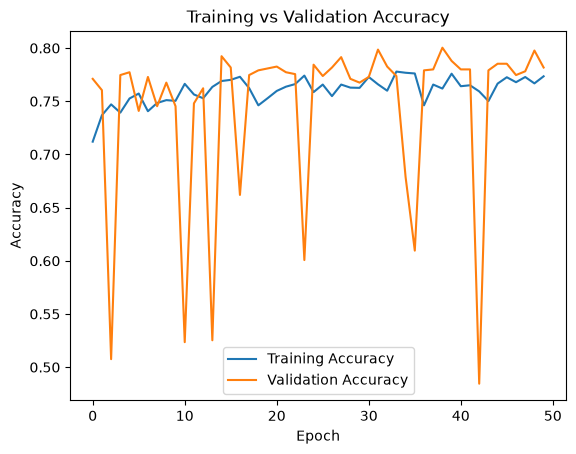

In [121]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Visualize Training and Validation Loss

Loss represents the error made by the neural network.

We compare training loss and validation loss across epochs
to understand how well the model is learning.

A decreasing loss generally indicates that the model is improving.

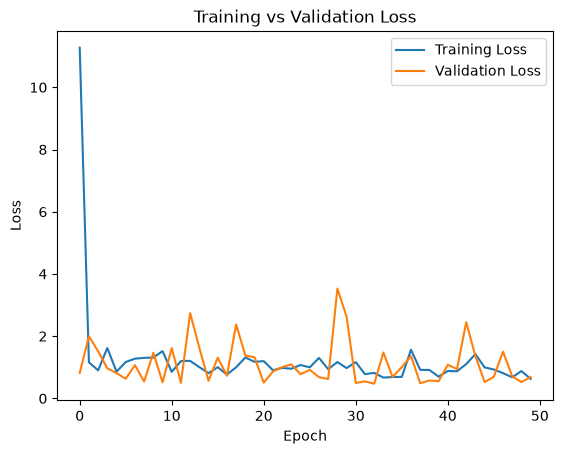

In [122]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluating ANN on Test Data

The test dataset contains customers that were not used during model training.
We evaluate the trained ANN on this unseen data to measure how well
it generalizes to new customers.

In [123]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("test_accuracy:", test_accuracy)

Test loss: 0.6312612891197205
test_accuracy: 0.8005678057670593


## Generate Predictions

The ANN outputs a probability between 0 and 1 because the output layer
uses the sigmoid activation function.

We convert these probabilities into class predictions:

- Probability >= 0.5 → Churn (1)
- Probability < 0.5 → No Churn (0)

In [124]:
y_pred_prob = model.predict(x_test)

y_pred = (y_pred_prob >=0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


## 32. Confusion Matrix

A confusion matrix shows how many predictions were:

True Positive (TP), True Negative (TN) ,False Positive (FP), False Negative (FN)

It helps us understand the types of mistakes made by the ANN.

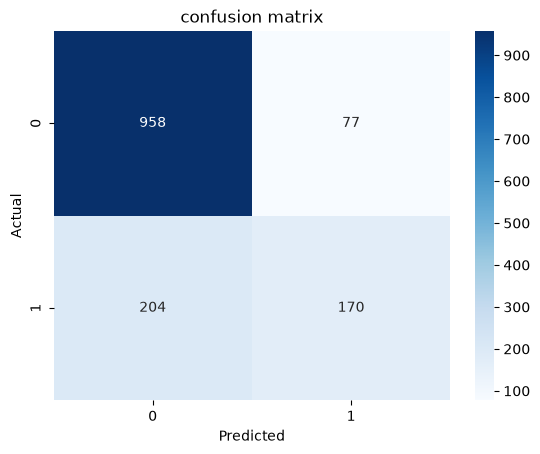

In [125]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Precision, Recall and F1-Score

Accuracy alone is not enough for evaluating customer churn.

We use precision, recall, and F1-score to understand how well
the model identifies customers who are likely to churn.

- Precision 
- Recall 
- F1-score

In [126]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1035
           1       0.69      0.45      0.55       374

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



## Improve the ANN Using Dropout

Dropout is a regularization technique used to reduce overfitting.

During training, dropout randomly turns off some neurons.
This forces the neural network to learn more robust patterns
instead of depending too heavily on specific neurons.

In [127]:
model_dropout = keras.Sequential([
    keras.Input(shape=(30,)),
    
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(1, activation="sigmoid")
])

In [128]:

# compile
model_dropout.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

In [129]:
model_dropout.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the ANN with Dropout

The improved ANN is trained using Dropout regularization.
Dropout helps the model learn more robust patterns by randomly
deactivating some neurons during training.

We use the same training settings as the original model so that
we can make a fair comparison between the two models.

In [130]:
history_dropout = model_dropout.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6499 - loss: 44.2772 - val_accuracy: 0.7462 - val_loss: 15.8944
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6503 - loss: 16.7585 - val_accuracy: 0.4011 - val_loss: 1.6571
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6244 - loss: 5.3773 - val_accuracy: 0.6477 - val_loss: 0.6449
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6341 - loss: 2.3731 - val_accuracy: 0.7462 - val_loss: 0.6716
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7118 - loss: 1.3395 - val_accuracy: 0.7382 - val_loss: 0.6292
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7238 - loss: 1.0487 - val_accuracy: 0.7382 - val_loss: 0.5965
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7340 - loss: 0.8469 - val_accuracy: 0.7382 - val_loss: 0.5764
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7313 - loss: 0.8852 - val_accuracy:

## Evaluate the Improved ANN

The improved ANN is evaluated using the same test dataset as the
original ANN.
This allows us to fairly compare the performance of both models.

In [131]:
test_loss_dropout, test_accuracy_dropout = model_dropout.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("improved test loss: ", test_loss_dropout)
print("improved test accuracy: ", test_accuracy_dropout)

improved test loss:  0.48232463002204895
improved test accuracy:  0.7877927422523499


## Evaluate the Improved ANN

We generate predictions from the ANN with Dropout and calculate
precision, recall, and F1-score.

These metrics help us determine whether Dropout improved the
model's ability to identify customers who churn.

In [132]:
y_pred_dropout_prob = model_dropout.predict(x_test)

y_pred_dropout = (y_pred_dropout_prob >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [133]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_dropout))

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1035
           1       0.71      0.33      0.46       374

    accuracy                           0.79      1409
   macro avg       0.76      0.64      0.66      1409
weighted avg       0.78      0.79      0.76      1409



## Handle Class Imbalance Using Class Weights

The dataset contains more non-churn customers than churn customers.

Class weights assign greater importance to the minority class during
training. This encourages the ANN to pay more attention to customers
who are likely to churn.

We calculate the class weights from the training labels.

In [134]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights

array([0.68059918, 1.88428094])

In [135]:
# converting into dictionary

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

class_weight_dict

{0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}

##  Build the Class-Weighted ANN

The class-weighted ANN uses the same architecture as the original model.

Class weights will be applied during training so that mistakes involving
the minority churn class receive greater importance.

This may improve the model's ability to identify customers who churn.

In [136]:
model_weighted = keras.Sequential([
    keras.Input(shape=(30,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


In [137]:

# compilation 
model_weighted.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

In [138]:
# checking the model

model_weighted.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Class-Weighted ANN

The class-weighted ANN is trained using the calculated class weights.

The `class_weight` parameter gives more importance to the minority
Churn class during training.

This encourages the model to pay more attention to identifying
customers who are likely to churn.

In [139]:
history_weighted = model_weighted.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50


141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6379 - loss: 12.1542 - val_accuracy: 0.6664 - val_loss: 0.8378
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6829 - loss: 0.8973 - val_accuracy: 0.7045 - val_loss: 0.6177
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6827 - loss: 0.9951 - val_accuracy: 0.7187 - val_loss: 0.5556
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6960 - loss: 0.8648 - val_accuracy: 0.7267 - val_loss: 0.5501
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7014 - loss: 0.8225 - val_accuracy: 0.7311 - val_loss: 0.5124
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7222 - loss: 0.7314 - val_accuracy: 0.7622 - val_loss: 1.3965
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6949 - loss: 1.0347 - val_accuracy: 0.7551 - val_loss: 0.6101
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7169 - loss: 0.7468 - val_accuracy: 0.7604 - val

## Evaluate the Class-Weighted ANN

The class-weighted ANN is evaluated on the same unseen test dataset.

We will compare its performance with the original ANN and the
Dropout ANN.

In [140]:
test_loss_weighted, test_accuracy_weighted = model_weighted.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Weighted Test Loss:", test_loss_weighted)
print("Weighted Test Accuracy:", test_accuracy_weighted)

Weighted Test Loss: 0.5370209813117981
Weighted Test Accuracy: 0.7303051948547363


In [141]:
y_pred_weighted_prob = model_weighted.predict(x_test)

y_pred_weighted = (y_pred_weighted_prob >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [142]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.75      1409



## Early Stopping

Early Stopping is a technique used to prevent overfitting.

It monitors the validation performance during training and stops
training when the model stops improving.

The best model weights are restored after training.

In [143]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## Build the Final Candidate ANN

The final candidate model uses the original ANN architecture.

We will combine this model with class weighting and early stopping
during training.

In [144]:
model_final = keras.Sequential([
    keras.Input(shape=(30,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [145]:
# compilation

model_final.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

In [146]:
history_final = model_final.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6423 - loss: 1.1095 - val_accuracy: 0.4330 - val_loss: 2.7947
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6754 - loss: 1.2022 - val_accuracy: 0.6939 - val_loss: 0.5764
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7007 - loss: 0.8779 - val_accuracy: 0.7187 - val_loss: 0.5339
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6845 - loss: 0.9586 - val_accuracy: 0.4658 - val_loss: 1.7765
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6945 - loss: 0.8949 - val_accuracy: 0.6912 - val_loss: 0.5798
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6934 - loss: 0.9472 - val_accuracy: 0.7036 - val_loss: 0.5565
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6976 - loss: 0.9245 - val_accuracy: 0.7684 - val_loss: 0.6740
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6885 - loss: 0.9712 - val_accuracy: 0.

## Evaluate the Final Candidate Model

The final candidate ANN combines class weighting with early stopping.

We evaluate it on the same unseen test dataset used for all previous models.

This allows us to compare the final candidate fairly with the original
and improved models.

In [147]:
final_loss, final_accuracy = model_final.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Final Test Loss:", final_loss)
print("Final Test Accuracy:", final_accuracy)

Final Test Loss: 0.5072936415672302
Final Test Accuracy: 0.733853816986084


In [148]:
# Generate prediction

y_pred_final_prob = model_final.predict(x_test)

y_pred_final = (y_pred_final_prob >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [149]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409



## ROC-AUC Evaluation

ROC-AUC measures how well the model distinguishes between churn
and non-churn customers across different classification thresholds.

A higher ROC-AUC indicates better ability to separate the two classes.

The ROC-AUC score ranges from 0 to 1.

In [150]:
from sklearn.metrics import roc_auc_score

roc_auc_score = roc_auc_score(
    y_test,
    y_pred_weighted_prob
)

print("ROC-AUC Score:", roc_auc_score)

ROC-AUC Score: 0.831705804851585


## ROC Curve

The ROC curve shows how the model's True Positive Rate
changes against its False Positive Rate at different
classification thresholds.

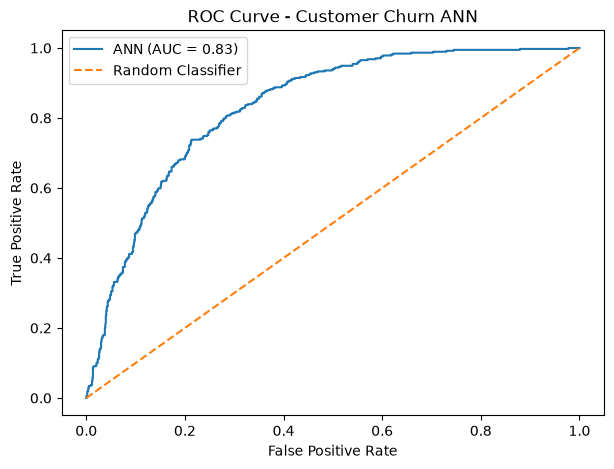

In [151]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_weighted_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn ANN")
plt.legend()
plt.show()

## Save the Final ANN Model

We save the selected class-weighted ANN model so that it can be
loaded later without retraining.

The saved model will be used in the Streamlit deployment.

In [152]:
model_weighted.save("customer_churn_ann.keras")

In [153]:
import os

print(os.path.exists("customer_churn_ann.keras"))

True


## Save the Feature Scaler

The ANN was trained using scaled features.

We save the same scaler so that new customer data in the Streamlit
application is transformed in exactly the same way as the training data.

In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [160]:
# Save the trained ANN model
import joblib

joblib.dump(model_final, "customer_churn_ann.pkl")

print("Model saved successfully!")

Model saved successfully!


In [161]:
# Save the Feature Scaler
joblib.dump(scaler, "scaler.pkl")

print("scaler saved successfully !")

scaler saved successfully !


In [163]:
# Save the feature column names

feature_columns = x_train.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print('Featured Columns Saved Successfully !')
print(len(feature_columns))

Featured Columns Saved Successfully !
30


In [164]:
# verify

import os

print(os.listdir())

['customer_churn_ann.ipynb', 'customer_churn_ann.keras', 'customer_churn_ann.pkl', 'feature_columns.pkl', 'scaler.pkl']
